In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [2]:
url = 'https://raw.githubusercontent.com/atilsamancioglu/MachineLearningNotebooks/refs/heads/main/26-customer_data.csv'

df = pd.read_csv(url)

df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.5 KB


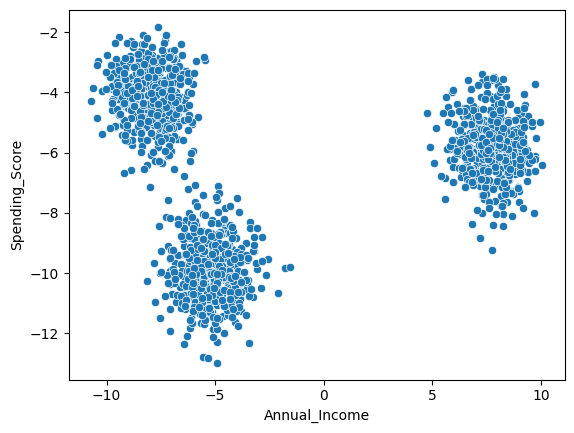

In [4]:
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score')
plt.show()

In [5]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=15)
X_train, X_test

(      Annual_Income  Spending_Score
 258        7.809992       -5.031123
 195        7.769519       -6.059915
 817       -8.529586       -4.853877
 820       -5.765759       -9.822013
 716       -7.932068       -4.882406
 ...             ...             ...
 667       -6.734875       -5.107626
 156       -8.236823       -3.127431
 384       -7.744180       -3.563590
 645       -6.151325       -9.263209
 1480      -8.413924       -5.354832
 
 [1199 rows x 2 columns],
       Annual_Income  Spending_Score
 513       -5.172436      -11.041683
 906       -7.281623       -4.334985
 1366      -7.933360       -4.679263
 367        7.247201       -4.157474
 1392      -5.963997       -9.834777
 ...             ...             ...
 879       -4.747040       -9.904793
 722       -4.886108      -10.754440
 557        7.764069       -4.766483
 1230      -5.160849      -10.713683
 794        7.345305       -5.608936
 
 [300 rows x 2 columns])

In [6]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Elbow Method
wcss = []
for k in range (1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++'
    )
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
wcss

[196.9206878471016,
 68.44836482219306,
 11.697030239519936,
 9.894467336616092,
 7.808868079302213,
 6.08811785401941,
 5.580606780011806,
 4.9958558746490285,
 4.636562303802592,
 4.116477682420991]

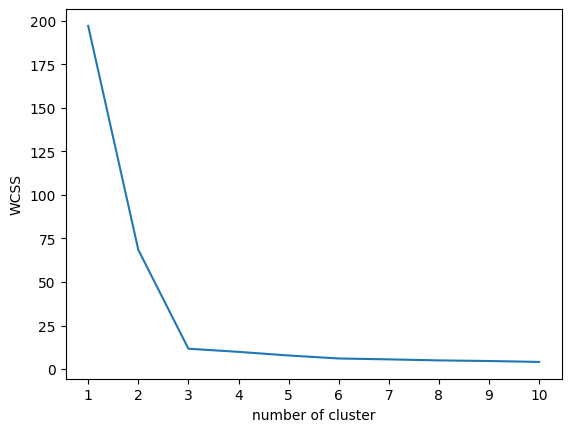

In [8]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel('number of cluster')
plt.ylabel('WCSS')
plt.show()

In [9]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_train_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [11]:
y_pred = kmeans.predict(X_test_scaled)

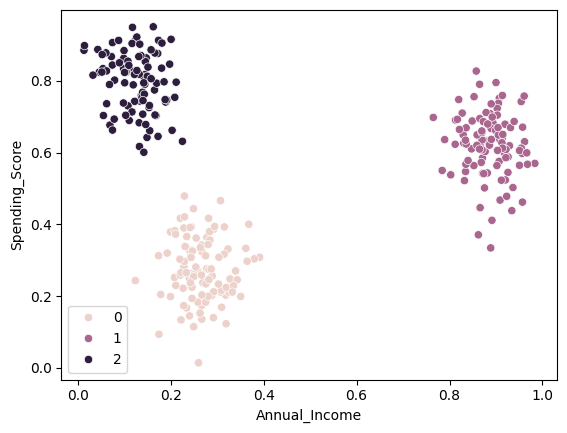

In [13]:
sns.scatterplot(
    pd.DataFrame(X_test_scaled, columns=X_test.columns),
    x='Annual_Income',
    y='Spending_Score',
    hue=y_pred
)
plt.show()

In [18]:
kl = KneeLocator(range(1,11), wcss,curve ='convex', direction='decreasing')

In [23]:
kl.elbow

np.int64(3)